# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## What Is DBSCAN?

DBSCAN is a **density-based clustering algorithm** that groups together points that are closely packed in space, and marks points in sparse regions as **noise (outliers)**. Unlike K-Means, it requires no specification of the number of clusters $K$ — the number of clusters emerges naturally from the structure of the data.

Two fundamental differences from K-Means:

- It makes **no assumption about cluster shape** — clusters can be arbitrary, non-convex, and irregularly shaped
- It **explicitly identifies outliers** rather than forcing every point into a cluster

## Core Concepts: The Two Parameters

DBSCAN is controlled by exactly two parameters:

- $\varepsilon$ **(epsilon)** — the radius of the neighborhood around each point
- $\text{minPts}$ — the minimum number of points required within radius $\varepsilon$ for a region to be considered dense

Every point in the dataset is classified into one of three types based on these parameters.

### $\varepsilon$-Neighborhood

The $\varepsilon$-neighborhood of a point $\mathbf{x}_i$ is the set of all points within distance $\varepsilon$:

$$N_\varepsilon(\mathbf{x}_i) = \left\{ \mathbf{x}_j : \|\mathbf{x}_j - \mathbf{x}_i\| \leq \varepsilon \right\}$$

### Types of Points

**Core Point** — a point with at least $\text{minPts}$ neighbors within $\varepsilon$:

$$|N_\varepsilon(\mathbf{x}_i)| \geq \text{minPts}$$

Core points lie in dense regions and act as the seeds from which clusters grow.

**Border Point** — a point that is not a core point itself, but falls within the $\varepsilon$-neighborhood of at least one core point. It belongs to the cluster of that core point but does not expand it further.

**Noise Point** — a point that is neither a core point nor reachable from any core point. These are the **outliers** — isolated points in sparse regions that do not belong to any cluster.

## Density Reachability and Connectivity

These two concepts define how clusters are formed.

**Direct Density Reachability:** Point $\mathbf{x}_j$ is directly density-reachable from $\mathbf{x}_i$ if:

1. $\mathbf{x}_i$ is a core point
2. $\mathbf{x}_j \in N_\varepsilon(\mathbf{x}_i)$

Note this relationship is **not symmetric** — $\mathbf{x}_j$ may be reachable from $\mathbf{x}_i$ without $\mathbf{x}_i$ being reachable from $\mathbf{x}_j$ (if $\mathbf{x}_j$ is a border point).

**Density Reachability (Chaining):** $\mathbf{x}_j$ is density-reachable from $\mathbf{x}_i$ if there exists a chain of points $\mathbf{x}_i, p_1, p_2, \ldots, \mathbf{x}_j$ where each step is a direct density-reachable connection. This allows clusters to extend through winding, non-spherical shapes.

**Density Connectivity:** Two points $\mathbf{x}_i$ and $\mathbf{x}_j$ are density-connected if there exists a core point $\mathbf{x}_k$ from which both are density-reachable. A cluster is defined as a maximal set of density-connected points.

## The Algorithm

1. Pick any unvisited point $\mathbf{x}_i$
2. Compute its $\varepsilon$-neighborhood $N_\varepsilon(\mathbf{x}_i)$
3. If $|N_\varepsilon(\mathbf{x}_i)| \geq \text{minPts}$ — $\mathbf{x}_i$ is a **core point**: start a new cluster and recursively expand it by adding all density-reachable points
4. If $|N_\varepsilon(\mathbf{x}_i)| < \text{minPts}$ — temporarily mark $\mathbf{x}_i$ as **noise** (it may later be absorbed as a border point when a nearby core point is processed)
5. Repeat until all points are visited

The cluster grows **outward** from each core point like an expanding density bubble, absorbing all reachable points regardless of shape.

## No Global Objective Function

K-Means minimizes a clean global objective (WCSS). DBSCAN has **no equivalent**. There is no cost function being optimized — the algorithm is entirely procedural, based on local density conditions.

This is both a strength and a limitation. It is a strength because the algorithm is not biased toward any particular cluster geometry. It is a limitation because there is no obvious scalar quantity to track or minimize during parameter selection.

## Choosing the Parameters

### Choosing $\text{minPts}$

A standard rule of thumb:

$$\text{minPts} \geq d + 1$$

Where $d$ is the number of features (dimensionality). In practice, values between 4 and 10 work well for most problems. Higher $\text{minPts}$ requires denser regions to form clusters, making the algorithm more conservative and producing more noise points.

### Choosing $\varepsilon$ — The K-Distance Graph

The most principled method for selecting $\varepsilon$ is the **k-distance graph**:

1. For each point, compute the distance to its $k$-th nearest neighbor (using $k = \text{minPts}$)
2. Sort these distances in ascending order
3. Plot the sorted distances
4. Find the **elbow** — the point of maximum curvature where the distances begin to rise sharply

The $\varepsilon$ corresponding to the elbow is a good choice. Points to the right of the elbow are in sparse regions and will be classified as noise; points to the left are in dense regions and will form clusters.

## Evaluation Metrics

Since DBSCAN produces no labels from a supervised target, clustering quality is assessed with internal metrics.

### Silhouette Score

$$s = \frac{b - a}{\max(a,\ b)}$$

Where $a$ is the mean intra-cluster distance and $b$ is the mean distance to the nearest other cluster. Scores near $+1$ indicate well-separated clusters. Note that noise points (label $= -1$) must be excluded when computing this score, as they do not belong to any cluster.

### Davies-Bouldin Score

Measures the average similarity between each cluster and its most similar neighbor. **Lower is better.** It is defined as:

$$DB = \frac{1}{K}\sum_{i=1}^{K} \max_{j \neq i} \left( \frac{\sigma_i + \sigma_j}{d(\mu_i, \mu_j)} \right)$$

Where $\sigma_i$ is the mean distance of points in cluster $i$ to centroid $\mu_i$, and $d(\mu_i, \mu_j)$ is the distance between centroids. A lower score means clusters are compact and well-separated.

### Adjusted Rand Index (ARI)

Used only when **true labels are known** (e.g. synthetic data). It measures the agreement between the true partition and the discovered clustering, adjusted for chance. A score of $1$ means perfect agreement; $0$ means random labeling.

## DBSCAN vs K-Means

| Aspect | K-Means | DBSCAN |
|---|---|---|
| Number of clusters | Must specify $K$ | Determined automatically |
| Cluster shape | Spherical only | Arbitrary |
| Outlier handling | Forced into nearest cluster | Explicitly labeled as noise |
| Optimization | Minimizes WCSS | No global objective — density expansion |
| Parameters | $K$ | $\varepsilon$, $\text{minPts}$ |
| Equal density assumption | Yes | Yes (shared limitation) |
| Scalability | Good | Moderate — $\mathcal{O}(n^2)$ without indexing |

### Geometric Intuition

K-Means draws **circles (Voronoi regions) around centroids** and assigns every point to the nearest one. The boundary between clusters is always a straight line in feature space.

DBSCAN **expands density bubbles** outward from core points, following the shape of the data regardless of geometry. There are no centroids and no straight boundaries — only the local connectivity of dense regions.

## Limitations

**Varying density:** DBSCAN uses a single global $\varepsilon$. If some clusters are denser than others, no single $\varepsilon$ works well for all of them simultaneously. One region's signal is another's noise. The **HDBSCAN** algorithm (Hierarchical DBSCAN) addresses this by building a cluster hierarchy across multiple density levels.

**Parameter sensitivity:** The results can change dramatically with small changes in $\varepsilon$. Selecting the right value requires the k-distance graph method and domain understanding — there is no automated equivalent of the silhouette score for parameter selection.

**High dimensions:** In high-dimensional spaces, distances between points become increasingly similar — the curse of dimensionality. When all pairwise distances are roughly equal, the concept of a meaningful $\varepsilon$-neighborhood breaks down. Dimensionality reduction (e.g. PCA or UMAP) before applying DBSCAN is recommended for high-dimensional data.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

X, _ = make_moons(n_samples=500, noise=0.1, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

In [20]:
unique_labels = set(labels)

if len(unique_labels) > 1 and -1 not in unique_labels:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)

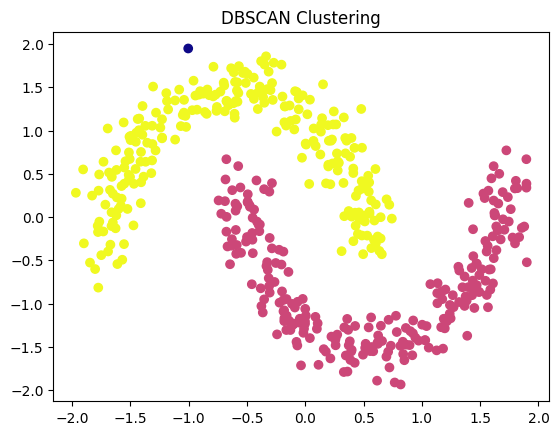

In [21]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=labels, cmap='plasma')

plt.title("DBSCAN Clustering")
plt.show()